# Start

In [1]:
# # Code pour vider un dossier
# import os
# import shutil

# def clear_directory(path):
#     """
#     Supprime récursivement tout le contenu d'un répertoire donné,
#     puis recrée le répertoire vide.
#     """
#     if os.path.exists(path):
#         print(f"Suppression du contenu du dossier : {path}")
#         shutil.rmtree(path)
#         print(f"Dossier {path} et son contenu supprimés.")
#     else:
#         print(f"Le dossier {path} n'existe pas, pas de suppression nécessaire.")

#     os.makedirs(path, exist_ok=True)
#     print(f"Dossier {path} recréé et vide.")

# # --- Exemple d'utilisation (décommenter et remplacer 'YOUR_PATH_HERE') ---
# # ATTENTION: Assurez-vous que le chemin est correct, cette opération est irréversible.
# path_to_clear = "/content/drive/MyDrive/P8/Experiences/checkpoints"
# clear_directory(path_to_clear)


## Imports

In [2]:
import pandas as pd
import os
import numpy as np
import tensorflow as tf
import cv2
from glob import glob
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras import callbacks, losses, metrics, optimizers
from tensorflow.keras import applications
import shutil
import numpy as np

from pathlib import Path

!pip install mlflow -q
!pip install Pillow -q
import mlflow.tensorflow
import mlflow
import warnings

# Supprimer tous les warnings
warnings.filterwarnings("ignore")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 113.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 123.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.3 MB/s eta 0:00:00


In [3]:
from tensorflow.keras import mixed_precision

# Activation de la politique "mixed_float16"
# Cela permet d'utiliser des float16 pour les calculs (rapide) et float32 pour les variables (stable)
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print('Mixed precision policy:', policy.compute_dtype)

Mixed precision policy: float16


## CONFIG PATHS

In [4]:
import os
from pathlib import Path
import mlflow

# --- CENTRALISATION DES CHEMINS (DRIVE) ---
PROJECT_ROOT = Path("/content/drive/MyDrive/P8")

# 1. Dossier Racine "Experiences"
EXP_ROOT = PROJECT_ROOT / "Experiences" / "Model_4_Resnet_UNet"

# 2. Sous-dossiers
# SEPARATION IMPORTANTE : On isole les logs MLflow dans 'mlruns'
# pour éviter qu'il ne scanne 'checkpoints' ou 'Models' comme des expériences.
MLFLOW_TRACKING_DIR = EXP_ROOT / "mlruns"
CHECKPOINTS_DIR     = EXP_ROOT / "checkpoints"
MODELS_DIR          = EXP_ROOT / "Models"

# Création automatique de l'arborescence
for path in [EXP_ROOT, MLFLOW_TRACKING_DIR, CHECKPOINTS_DIR, MODELS_DIR]:
    if not path.exists():
        print(f"📁 Création dossier : {path}")
        path.mkdir(parents=True, exist_ok=True)

# Configuration MLflow immédiate
mlflow.set_tracking_uri("file://" + str(MLFLOW_TRACKING_DIR))

print("\n✅ CONFIGURATION TERMINÉE (Structure corrigée)")
print(f"📡 MLflow Tracking URI : {mlflow.get_tracking_uri()}")
print(f"💾 Checkpoints : {CHECKPOINTS_DIR}")
print(f"📦 Modèles Finaux : {MODELS_DIR}")

📁 Création dossier : /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet
📁 Création dossier : /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/mlruns
📁 Création dossier : /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints
📁 Création dossier : /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/Models

✅ CONFIGURATION TERMINÉE (Structure corrigée)
📡 MLflow Tracking URI : file:///content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/mlruns
💾 Checkpoints : /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints
📦 Modèles Finaux : /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/Models


In [5]:
import os
from pathlib import Path
import mlflow

# Get the currently configured MLflow tracking URI
# Ensure MLFLOW_TRACKING_DIR is defined, if not, re-evaluate previous cells or set it here.
# Assuming MLFLOW_TRACKING_DIR from cell 'vzdfsFXfMy9c' is available:
mlflow_tracking_path = Path(mlflow.get_tracking_uri().replace("file://", ""))
mlflow_trash_dir = mlflow_tracking_path / ".trash"

# Create the .trash directory if it does not exist
if not mlflow_trash_dir.exists():
    try:
        mlflow_trash_dir.mkdir(parents=True, exist_ok=True)
        print(f"📁 Dossier MLflow .trash créé : {mlflow_trash_dir}")
    except Exception as e:
        print(f"⚠️ Erreur lors de la création du dossier MLflow .trash : {e}")
else:
    print(f"📁 Le dossier MLflow .trash existe déjà : {mlflow_trash_dir}")


📁 Dossier MLflow .trash créé : /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/mlruns/.trash


## Mounting Drive

In [7]:
import os
import shutil
from google.colab import drive

mount_point = '/content/drive'

# Check if the mount point exists and has contents
if os.path.exists(mount_point) and os.listdir(mount_point):
    print(f"Clearing existing contents in {mount_point} before mounting...")
    try:
        # Try to unmount first, in case it's a partially mounted or stale mount.
        # This command is often necessary before trying to clear or remount.
        _ = !fusermount -uz {mount_point}
        print(f"Successfully unmounted {mount_point}.")
    except Exception as e:
        print(f"Could not unmount {mount_point}: {e}. Proceeding with clearing directory.")

    # Remove all contents from the directory. If it was a broken mount, this cleans up.
    # If it's just a directory with files, this clears it for the mount.
    for item in os.listdir(mount_point):
        item_path = os.path.join(mount_point, item)
        try:
            if os.path.islink(item_path) or os.path.isfile(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
        except Exception as e:
            print(f"Error removing {item_path}: {e}. This might prevent successful mounting.")
            # We don't want to halt execution here, as drive.mount will raise if it's still an issue.

drive.mount(mount_point, force_remount=True)

Mounted at /content/drive


## Initializing Repository

In [8]:
import os
import glob

# 1. Définition des Chemins
# DRIVE_SOURCE = "/content/drive/MyDrive/P8"   # Là où sont stockés vos zips (Source lente)
DRIVE_SOURCE = "/content/drive/MyDrive/P8/Data" # Essayez celui-ci si le premier ne trouve rien

LOCAL_DEST = "/content/P8/Data"              # Là où on veut travailler (Destination rapide)

print(f"🔄 Initialisation de la copie : Drive -> {LOCAL_DEST}")

if not os.path.exists(LOCAL_DEST):
    os.makedirs(LOCAL_DEST)

# 2. Recherche automatique des fichiers ZIP sur le Drive
# On cherche tout ce qui commence par 'P8_Cityscapes' et finit par '.zip'
found_zips = glob.glob(os.path.join(DRIVE_SOURCE, "**", "P8_Cityscapes*.zip"), recursive=True)

if not found_zips:
    print("❌ ERREUR CRITIQUE : Aucun fichier zip trouvé dans le Drive !")
    print(f"J'ai cherché dans : {DRIVE_SOURCE}")
    print("Vérifiez le chemin exact dans la colonne de gauche 'drive > MyDrive > ...'")
else:
    print(f"✅ Fichiers ZIP trouvés sur le Drive : {len(found_zips)}")
    for zip_file in found_zips:
        print(f"   -> Copie et Décompression de : {os.path.basename(zip_file)} ...")
        # Unzip silencieux (-q) mais avec écrasement (-o) vers le dossier local
        !unzip -q -o "{zip_file}" -d "{LOCAL_DEST}"

    print("\n🎉 SUCCESS : Toutes les données sont prêtes sur le Disque Rapide !")

    # 3. Configuration des variables GLOBALES
    IMG_DIR = os.path.join(LOCAL_DEST, "leftImg8bit")
    MASK_DIR = os.path.join(LOCAL_DEST, "gtFine")

    print(f"📁 IMG_DIR = {IMG_DIR}")
    if os.path.exists(IMG_DIR):
         print(f"   Contenu : {os.listdir(IMG_DIR)}")
    else:
         print("⚠️ Attention : Le dossier leftImg8bit n'est pas apparu. Vérifiez la structure du zip.")

🔄 Initialisation de la copie : Drive -> /content/P8/Data
✅ Fichiers ZIP trouvés sur le Drive : 2
   -> Copie et Décompression de : P8_Cityscapes_gtFine_trainvaltest.zip ...
   -> Copie et Décompression de : P8_Cityscapes_leftImg8bit_trainvaltest.zip ...

🎉 SUCCESS : Toutes les données sont prêtes sur le Disque Rapide !
📁 IMG_DIR = /content/P8/Data/leftImg8bit
   Contenu : ['train', 'val', 'test']


# Data Preparing

## Loading Data

In [9]:
from pathlib import Path
import os

# --- 1. CONFIGURATION DES CHEMINS ---

# DRIVE (Stockage Permanent Résultats)
PROJECT_ROOT = Path("/content/drive/MyDrive/P8")

# LOCAL (Stockage Temporaire Rapide pour Données)
# C'est ici que le script 'unzip' a déposé les images
DATA_DIR_LOCAL = Path("/content/P8/Data")

IMG_DIR = DATA_DIR_LOCAL / "leftImg8bit"
MASK_DIR = DATA_DIR_LOCAL / "gtFine"

# Vérification
print(f"📂 INPUT (Lecture Rapide) : {IMG_DIR} -> Exists? {IMG_DIR.exists()}")
print(f"💾 OUTPUT (Sauvegarde Drive) : {PROJECT_ROOT} -> Exists? {PROJECT_ROOT.exists()}")

if not IMG_DIR.exists():
    print("⚠️ ATTENTION : Les données locales ne sont pas trouvées. Avez-vous lancé le script 'Unzip' ?")

📂 INPUT (Lecture Rapide) : /content/P8/Data/leftImg8bit -> Exists? True
💾 OUTPUT (Sauvegarde Drive) : /content/drive/MyDrive/P8 -> Exists? True


In [10]:
print("Cities train images:", os.listdir(os.path.join(IMG_DIR, "train"))[:3])
print("Cities train masks:", os.listdir(os.path.join(MASK_DIR, "train"))[:3])

Cities train images: ['hanover', 'darmstadt', 'dusseldorf']
Cities train masks: ['hanover', 'darmstadt', 'dusseldorf']


## Fonction de listing image / masque

In [11]:
from glob import glob
from PIL import Image

def get_file_pairs(split="train"):
    img_paths = []
    mask_paths = []

    for city in os.listdir(os.path.join(IMG_DIR, split)):
        city_img_dir = os.path.join(IMG_DIR, split, city)
        city_mask_dir = os.path.join(MASK_DIR, split, city)

        for img_file in glob(os.path.join(city_img_dir, "*_leftImg8bit.png")):
            mask_file = os.path.join(
                city_mask_dir,
                os.path.basename(img_file).replace(
                    "_leftImg8bit.png",
                    "_gtFine_labelIds.png"
                )
            )

            if os.path.exists(mask_file):
                try:
                    with Image.open(img_file) as img_pil:
                        img_pil.verify()
                    with Image.open(mask_file) as mask_pil:
                        mask_pil.verify()

                    img_paths.append(img_file)
                    mask_paths.append(mask_file)
                except Exception as e:
                    print(f"Skipping corrupted image/mask pair (INVALID PNG DATA): {img_file}, {mask_file} - Error: {e}")
            else:
                print(f"Skipping image due to missing mask file: {img_file}")

    return img_paths, mask_paths


## Test du chargement des chemins

In [20]:
train_imgs, train_masks = get_file_pairs("train")
val_imgs, val_masks = get_file_pairs("val")

print(f"Train images: {len(train_imgs)}")
print(f"Val images: {len(val_imgs)}")

print(train_imgs[0])
print(train_masks[0])

Train images: 2975
Val images: 500
/content/P8/Data/leftImg8bit/train/bochum/bochum_000000_003674_leftImg8bit.png
/content/P8/Data/gtFine/train/bochum/bochum_000000_003674_gtFine_labelIds.png


## Chargement image + masque

In [21]:
import cv2
import numpy as np

IMG_HEIGHT = 256
IMG_WIDTH = 512

CITYSCAPES_TO_8 = {
    7: 0, 8: 0,
    11: 1, 12: 1,
    13: 2, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2,
    24: 3, 25: 3,
    21: 4,
    23: 5,
    19: 6, 20: 6, 22: 6,
    9: 7, 10: 7, 0: 7
}

def load_image_mask(img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.resnet_v2.preprocess_input(img)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT),
                      interpolation=cv2.INTER_NEAREST)

    new_mask = np.zeros_like(mask)
    for k, v in CITYSCAPES_TO_8.items():
        new_mask[mask == k] = v

    return img.numpy(), new_mask.astype(np.uint8)

# --- Création du Tenseur de Mapping pour TensorFlow ---
# On crée un tableau de mapping pour les IDs de 0 à 34 (max cityscapes id)
mapping = np.full(35, 7, dtype=np.int32) # Par défaut classe 7 (Void)
for k, v in CITYSCAPES_TO_8.items():
    if k < 35:
        mapping[k] = v

MAPPING_TENSOR = tf.constant(mapping)
print("✅ MAPPING_TENSOR créé pour le pipeline TF.")


✅ MAPPING_TENSOR créé pour le pipeline TF.


In [22]:
import albumentations as A

# --- Configuration Optimisation & Batch ---
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

# --- Data Augmentation avec Albumentations ---
# Pipeline améliorée avec Crop (40%), Rotation (30%), Shift & Scale
aug_pipeline = A.Compose([
    A.VerticalFlip(p=0.5),
    A.HorizontalFlip(p=0.5),
    # Crop avec redimensionnement pour garder 224x224 (p=0.4)
    # Correction : "size" ou "height" et "width" selon la version
    # Pour albumentations >= 1.4, c'est parfois "size"
    # Mais généralement height/width fonctionnent. Le message "Field required... size" suggère que l'init demande "size"
    # On va utiliser "size" si c'est une version très récente, ou revenir à une syntaxe sûre.
    # En fait, RandomResizedCrop accepte (height, width) historiquement, mais peut-être que l'appel a changé.
    # Essayons avec "size" si c'est ce qui est demandé, ou vérifions les args.
    # L'erreur "InitSchema size Field required" indique que Pydantic (utilisé par les nouvelles versions d'Albumentations) attend un tuple (height, width) dans un argument "size".
    A.RandomResizedCrop(size=(IMG_HEIGHT, IMG_WIDTH), scale=(0.7, 1.0), p=0.4),
    # Rotation (p=0.3)
    A.Rotate(limit=30, p=0.3),
    # Shift & Scale (Zoom/Décalage) - sans rotation car gérée au dessus
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.5),
    # Luminosité / Contraste
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.6)
])

def augment_albumentations(img, mask):
    # img is float32 [0,1], mask is int32
    data = {"image": img, "mask": mask}
    aug_data = aug_pipeline(**data)
    return aug_data["image"], aug_data["mask"]

def augment(img, mask):
    """ Data Augmentation via Albumentations wrapped in tf.numpy_function """
    aug_img, aug_mask = tf.numpy_function(
        func=augment_albumentations,
        inp=[img, mask],
        Tout=[tf.float32, tf.int32]
    )
    # Rétablissement des formes
    aug_img.set_shape((IMG_HEIGHT, IMG_WIDTH, 3))
    aug_mask.set_shape((IMG_HEIGHT, IMG_WIDTH, 1))
    
    return aug_img, aug_mask

def parse_image_mask(img_path, mask_path):
    """ Chargement standard """
    # 1. Image
    img = tf.io.read_file(img_path)
    img = tf.io.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.resnet_v2.preprocess_input(img)

    # 2. Masque
    mask = tf.io.read_file(mask_path)
    mask = tf.io.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_HEIGHT, IMG_WIDTH], method='nearest')
    mask = tf.cast(mask, tf.int32)

    # 3. Mapping
    mask = tf.gather(MAPPING_TENSOR, mask)

    return img, mask

def albumentations_augment(img, mask):
    """ Wrapper pour utiliser Albumentations dans TensorFlow """

    def aug_fn(image, mask):
        # Conversion TensorFlow -> Numpy
        data = {"image": image, "mask": mask}
        augmented = aug_pipeline(**data)
        return augmented["image"], augmented["mask"]

    # Appel via tf.numpy_function
    aug_img, aug_mask = tf.numpy_function(
        func=aug_fn,
        inp=[img, mask],
        Tout=[tf.float32, tf.int32]
    )

    # Restauration des formes (perdues par numpy_function)
    aug_img.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
    aug_mask.set_shape([IMG_HEIGHT, IMG_WIDTH, 1])

    return aug_img, aug_mask

def create_dataset(img_paths, mask_paths, training=False, augment_data=False):
    dataset = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))

    if training:
        dataset = dataset.shuffle(1000)

    # Parsing (Lecture fichiers)
    dataset = dataset.map(parse_image_mask, num_parallel_calls=AUTOTUNE)

    # Application Augmentation (Si training)
    if training and augment_data:
        dataset = dataset.map(albumentations_augment, num_parallel_calls=AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset


## Creating Datasets

In [23]:
# Train avec augmentation
train_ds_aug = create_dataset(train_imgs, train_masks, training=True, augment_data=True)
# Train sans augmentation (pour comparaison)
train_ds_no_aug = create_dataset(train_imgs, train_masks, training=True, augment_data=False)
# Validation (jamais d'augmentation)
val_ds = create_dataset(val_imgs, val_masks, training=False)

print(f"Datasets créés. Batch size: {BATCH_SIZE}")
# Vérification d'un batch
for img, mask in train_ds_aug.take(1):
    print(f"Image shape: {img.shape}, Type: {img.dtype}")
    print(f"Mask shape: {mask.shape}, Type: {mask.dtype}")

Datasets créés. Batch size: 32
Image shape: (32, 256, 512, 3), Type: <dtype: 'float32'>
Mask shape: (32, 256, 512, 1), Type: <dtype: 'int32'>


## Vérification de l'augmentation des données

Visualisation des échantillons SANS augmentation:


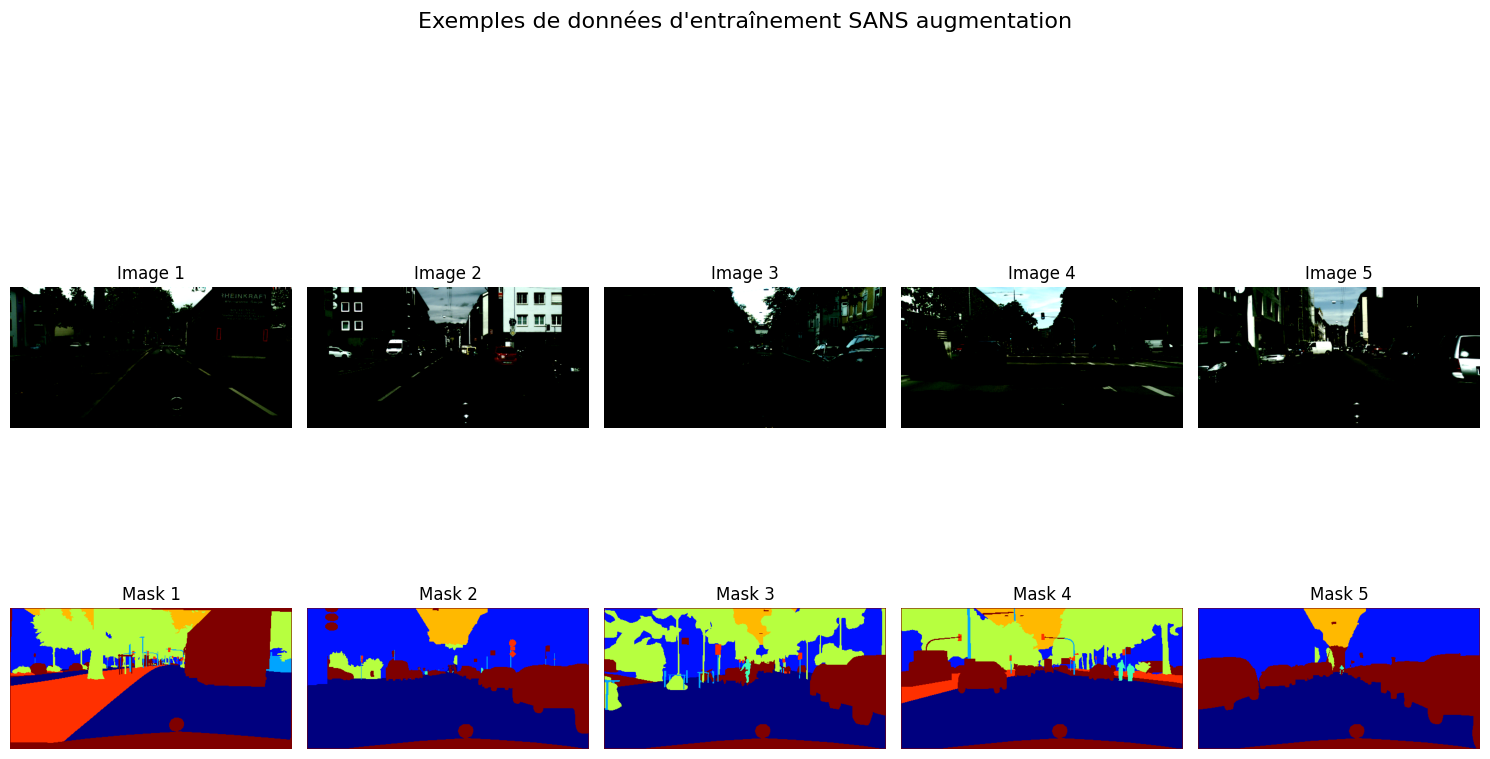


Visualisation des échantillons AVEC augmentation:


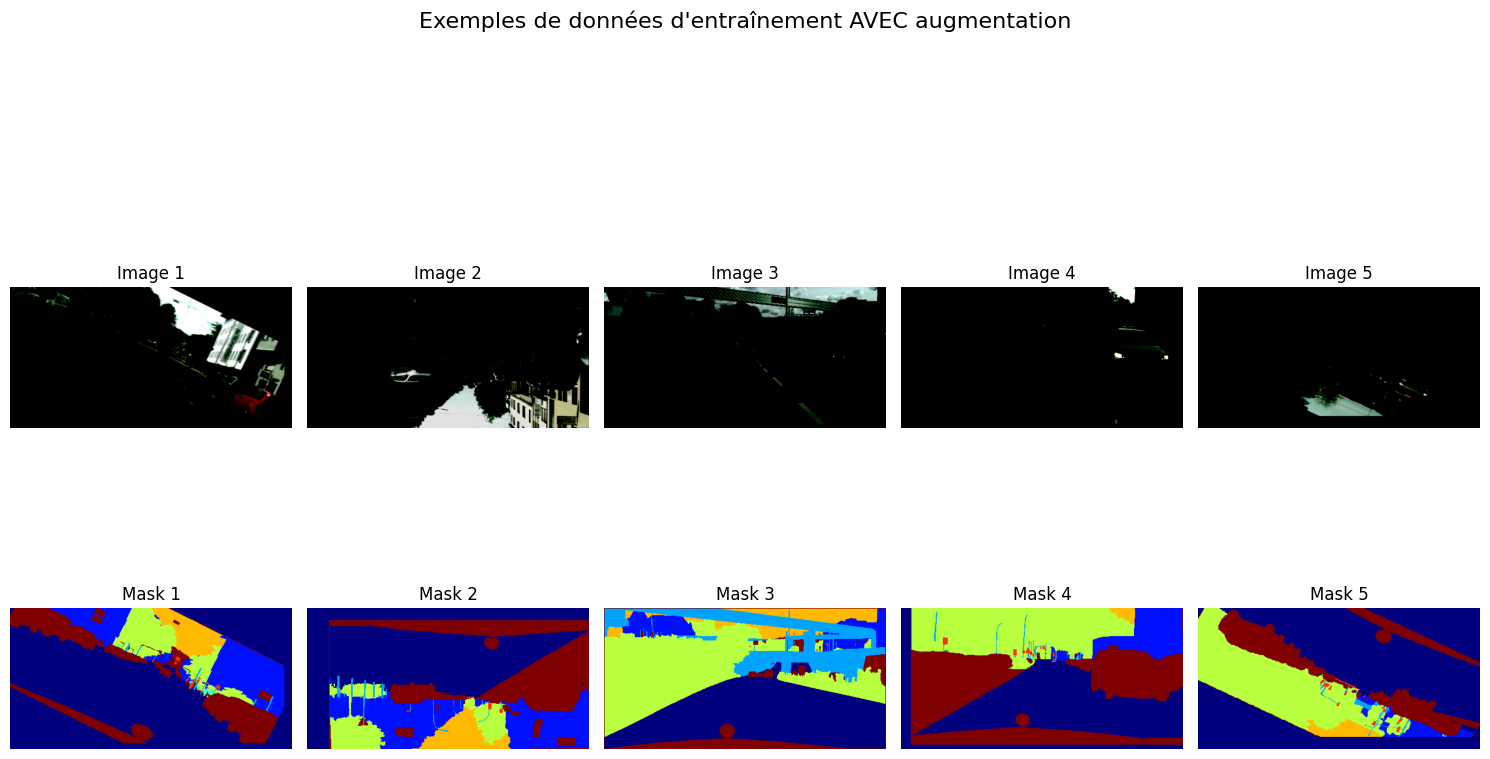

In [24]:
import matplotlib.pyplot as plt

def visualize_augmented_samples(dataset, title, num_samples=5):
    plt.figure(figsize=(15, 2 * num_samples))
    plt.suptitle(title, fontsize=16)

    for i, (images, masks) in enumerate(dataset.take(1)):
        if i >= num_samples:
            break

        for j in range(num_samples):
            if j >= images.shape[0]: # Ensure we don't go out of bounds if batch size is smaller than num_samples
                break

            # Image
            plt.subplot(2, num_samples, j + 1)
            plt.imshow(images[j])
            plt.title(f"Image {j+1}")
            plt.axis("off")

            # Mask
            plt.subplot(2, num_samples, num_samples + j + 1)
            plt.imshow(masks[j], cmap='jet', vmin=0, vmax=7) # Using cmap='jet' for better visibility of classes
            plt.title(f"Mask {j+1}")
            plt.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("Visualisation des échantillons SANS augmentation:")
visualize_augmented_samples(train_ds_no_aug, "Exemples de données d'entraînement SANS augmentation", num_samples=5)

print("\nVisualisation des échantillons AVEC augmentation:")
visualize_augmented_samples(train_ds_aug, "Exemples de données d'entraînement AVEC augmentation", num_samples=5)

## Visualisation d'un exemple

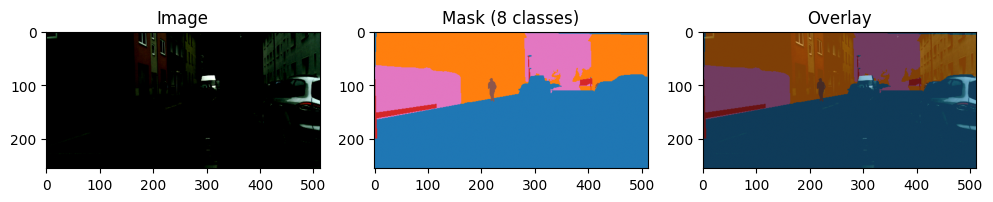

In [25]:
import matplotlib.pyplot as plt

img, mask = load_image_mask(train_imgs[0], train_masks[0])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="tab10")
plt.title("Mask (8 classes)")

plt.subplot(1,3,3)
plt.imshow(img)
plt.imshow(mask, cmap="tab10", alpha=0.5)
plt.title("Overlay")

plt.show()

# Modeling

## Loss Function for optimizing

In [37]:
# --- Définition de la Dice Loss Custom ---
def dice_loss(y_true, y_pred):
    """
    Dice Loss pour segmentation multiclasse
    y_true: labels sparse (batch, h, w, 1) ou (batch, h, w)
    y_pred: probabilités (batch, h, w, num_classes)
    """
    y_true = tf.cast(y_true, tf.int32)
    # One-hot encoding du masque réel pour matcher la forme de y_pred
    y_true_one_hot = tf.one_hot(tf.squeeze(y_true), depth=8) # 8 classes

    numerator = 2 * tf.reduce_sum(y_true_one_hot * y_pred, axis=(0,1,2))
    denominator = tf.reduce_sum(y_true_one_hot + y_pred, axis=(0,1,2))

    # Dice par classe (ajout d'un epsilon pour éviter division par 0)
    dice_score = (numerator + 1e-7) / (denominator + 1e-7)

    # On renvoie 1 - dice_moyen
    return 1 - tf.reduce_mean(dice_score)

# --- Définition de la Loss Combinée (Combo Loss) ---
def combo_loss(y_true, y_pred):
    # Poids pour équilibrer (souvent 1:1 marche bien)
    ce = losses.sparse_categorical_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return ce + dice

# --- Mise à jour de la configuration ---
# On utilise maintenant notre combo_loss au lieu de juste Crossentropy
# loss_fn = losses.SparseCategoricalCrossentropy()  <-- Ancienne
loss_fn = combo_loss  # <-- Nouvelle
optimizer = optimizers.Adam(learning_rate=1e-5)

## Training function

In [38]:
class UpdatedMeanIoU(tf.keras.metrics.MeanIoU):
    """
    Version de MeanIoU capable de gérer les sorties de probabilités (Softmax).
    Elle prend l'argmax (la classe la plus probable) avant de calculer l'IoU.
    """
    def __init__(self, num_classes, name=None, dtype=None, **kwargs):
        super(UpdatedMeanIoU, self).__init__(num_classes=num_classes, name=name, dtype=dtype, **kwargs)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # On transforme les probabilités (Batch, H, W, 8) en labels (Batch, H, W)
        y_pred = tf.math.argmax(y_pred, axis=-1)

        # On s'assure que tout est au bon format
        y_true = tf.cast(y_true, self.dtype)
        y_pred = tf.cast(y_pred, self.dtype)

        return super(UpdatedMeanIoU, self).update_state(y_true, y_pred, sample_weight)

# --- 3. FONCTION TRAIN_MODEL (Version Finale) ---

def train_model(model, train_ds, val_ds, run_name, epochs=15):
    print(f"\n🚀 DÉMARRAGE RUN : {run_name}")

    # A. Préparation Checkpoint (Sur le Drive)
    run_ckpt_dir = CHECKPOINTS_DIR / run_name
    if not run_ckpt_dir.exists():
        run_ckpt_dir.mkdir(parents=True, exist_ok=True)

    ckpt_path = str(run_ckpt_dir / "best_model.keras")
    print(f"💾 Checkpoints : {ckpt_path}")

    # B. Callbacks
    ckpt_callback = callbacks.ModelCheckpoint(
        filepath=ckpt_path,
        save_best_only=True,
        monitor="val_loss",
        mode="min",
        verbose=1
    )
    es_callback = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    # LR Scheduler: ReduceLROnPlateau
    lr_callback = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.8,
        patience=5,
        verbose=1,
        min_lr=1e-6
    )

    # C. Compilation
    # Création d'un nouvel optimiseur pour éviter les erreurs de variables inconnues
    optimizer = optimizers.Adam(learning_rate=1e-3)
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"], run_eagerly=True)

    # D. MLflow Run
    mlflow.set_experiment("Segmentation_Model_4_Resnet_UNet")

    with mlflow.start_run(run_name=run_name) as run:
        # Log params
        mlflow.log_params({
            "model": model.name,
            "epochs": epochs,
            "optimizer": "adam",
            "loss": "combo_loss" if loss_fn == combo_loss else "scce",
            "aug": "albumentations"
        })

        # Autolog (courbes) sans les modèles lourds
        mlflow.tensorflow.autolog(log_models=False)

        # Entraînement
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            callbacks=[ckpt_callback, es_callback, lr_callback]
        )

        # --- E. Évaluation Détaillée (IoU / Dice / Matrice de Confusion) ---
        print("\n📊 Calcul des métriques détaillées par classe...")
        total_cm = np.zeros((8, 8))

        for images, masks in val_ds:
            preds = model.predict(images, verbose=0)
            preds_cls = np.argmax(preds, axis=-1)
            masks_np = masks.numpy().flatten()
            preds_np = preds_cls.flatten()

            # Confusion Matrix
            cm = tf.math.confusion_matrix(masks_np, preds_np, num_classes=8).numpy()
            total_cm += cm

        classes = ["flat", "human", "vehicle", "construction", "object", "nature", "sky", "void"]

        # --- SAUVEGARDE MATRICE DE CONFUSION (Image) ---
        plt.figure(figsize=(10, 8))
        import seaborn as sns
        sns.heatmap(total_cm, annot=True, fmt="g", cmap="Blues", xticklabels=classes, yticklabels=classes)
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix - {run_name}")
        cm_path = "confusion_matrix.png"
        plt.savefig(cm_path)
        plt.close()
        mlflow.log_artifact(cm_path)
        print(f"📉 Matrice de confusion sauvegardée : {cm_path}")

        # Calculs IoU / Dice
        iou_list = []
        dice_list = []

        print(f"\n{'CLASSE':<12} | {'IoU':<8} | {'Dice':<8}")
        print("-" * 35)

        for i in range(8):
            tp = total_cm[i, i]
            fp = np.sum(total_cm[:, i]) - tp
            fn = np.sum(total_cm[i, :]) - tp

            # IoU
            denom_iou = tp + fp + fn
            iou = tp / denom_iou if denom_iou > 0 else 0
            iou_list.append(iou)

            # Dice
            denom_dice = 2 * tp + fp + fn
            dice = 2 * tp / denom_dice if denom_dice > 0 else 0
            dice_list.append(dice)

            # Log & Print
            mlflow.log_metric(f"iou_class_{classes[i]}", iou)
            mlflow.log_metric(f"dice_class_{classes[i]}", dice)
            print(f"{classes[i]:<12} | {iou:.4f}   | {dice:.4f}")

        # Moyennes
        mean_iou = np.mean(iou_list)
        mean_dice = np.mean(dice_list)

        print("-" * 35)
        print(f"🏆 MEAN IoU: {mean_iou:.4f} | MEAN Dice: {mean_dice:.4f}")

        mlflow.log_metric("final_mean_iou", mean_iou)
        mlflow.log_metric("final_mean_dice", mean_dice)

        # Sauvegarde CSV
        df = pd.DataFrame({"Class": classes, "IoU": iou_list, "Dice": dice_list})
        csv_path = "classification_report.csv"
        df.to_csv(csv_path, index=False)
        mlflow.log_artifact(csv_path)

        # F. Sauvegarde Modèle Final (Format Keras 3 .keras)
        run_model_dir = MODELS_DIR / run_name
        if not run_model_dir.exists():
            run_model_dir.mkdir(parents=True, exist_ok=True)

        final_model_path = str(run_model_dir / "final_model.keras")
        model.save(final_model_path)
        print(f"📦 Modèle final sauvegardé : {final_model_path}")

        print(f"✅ Run terminé avec succès.")
        return history


## Model Resnet50 - Unet

In [39]:
import gc
tf.keras.backend.clear_session()
gc.collect()
def build_unet_resnet50(input_shape, num_classes=8):
    """
    U-Net Optimisé avec encodeur ResNet50 (Transfer Learning)
    Correction : Utilisation de depthwise_initializer et pointwise_initializer pour SeparableConv2D
    """
    inputs = layers.Input(shape=input_shape)

    # --- ENCODER (ResNet50) ---
    base_model = applications.ResNet50V2(
        input_tensor=inputs,
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    layer_names = [
        'conv1_conv',        # 64 filters -> 112x112
        'conv2_block3_out',  # 256 filters -> 56x56
        'conv3_block4_out',  # 512 filters -> 28x28
        'conv4_block6_out',  # 1024 filters -> 14x14
        'post_relu',  # 2048 filters -> 7x7 (Bottleneck)
    ]
    layers_output = [base_model.get_layer(name).output for name in layer_names]
    encoder = models.Model(inputs=base_model.input, outputs=layers_output)

    s1, s2, s3, s4, bottleneck = encoder(inputs)

    # --- DECODER OPTIMISÉ ---

    def upsample_block(x, skip, filters):
        # Upsampling (Conv2DTranspose reste standard)
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding='same', kernel_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        # Concatenation
        # ALIGNEMENT DYNAMIQUE (Fix formel des Tensors Keras)
        x = layers.Lambda(lambda t: tf.image.resize(t[0], tf.shape(t[1])[1:3]))([x, skip])
        x = layers.Concatenate()([x, skip])

        # Convolution SÉPARABLE : Correction des initializers
        # On remplace kernel_initializer par depthwise_initializer et pointwise_initializer
        x = layers.SeparableConv2D(filters, 3, padding='same',
                                   depthwise_initializer='he_normal',
                                   pointwise_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        x = layers.SeparableConv2D(filters, 3, padding='same',
                                   depthwise_initializer='he_normal',
                                   pointwise_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        return x

    # Décodage progressif avec MOINS de filtres
    d1 = upsample_block(bottleneck, s4, 256)
    d2 = upsample_block(d1, s3, 128)
    d3 = upsample_block(d2, s2, 64)
    d4 = upsample_block(d3, s1, 32)

    # Dernière montée d'échelle
    outputs = layers.Conv2DTranspose(16, 3, strides=2, padding='same', kernel_initializer='he_normal')(d4)
    outputs = layers.BatchNormalization()(outputs)
    outputs = layers.Activation('relu')(outputs)

    # Couche de sortie
    outputs = layers.Conv2D(num_classes, 1, activation='softmax', dtype='float32')(outputs)

    return models.Model(inputs, outputs, name="UNet_ResNet50")

# Instanciation
model_resnet = build_unet_resnet50(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=8
)
model_resnet.summary()

Model: "UNet_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 128, 256, │ 23,564,800 │ input_layer[0][0] │
│ (Functional)        │ 64), (None, 32,   │            │                   │
│                     │ 64, 256), (None,  │            │                   │
│                     │ 16, 32, 512),     │            │                   │
│                     │ (None, 8, 16,     │            │                   │
│                     │ 1024), (None, 8,  │            │                   │
│                     │ 16, 2048)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 32,    │  4,718,848 │ functional[0][4]  │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 32,    │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 16, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 8, 16,     │          0 │ activation[0][0], │
│                     │ 256)              │            │ functional[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 16,     │          0 │ lambda[0][0],     │
│ (Concatenate)       │ 1280)             │            │ functional[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 8, 16,     │    339,456 │ concatenate[0][0] │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 16,     │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 8, 16,     │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 8, 16,     │     68,096 │ activation_1[0][… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 16,     │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 8, 16,     │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 32,    │    295,040 │ activation_2[0][… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 32,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                 

 Total params: 29,228,024 (111.50 MB)

 Trainable params: 5,660,312 (21.59 MB)

 Non-trainable params: 23,567,712 (89.90 MB)

### Sans Data Augmentation

In [40]:
tf.keras.backend.clear_session()
try:
    del model_resnet
except:
    pass
import gc; gc.collect()
# --- Modèle 2 : U-Net ResNet50 ---

# Expérience 2.1 : SANS Augmentation (Baseline)
# ---------------------------------------------
# 1. Instanciation
model_resnet_no_aug = build_unet_resnet50(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=8
)

# 2. Entraînement
history_resnet_no_aug = train_model(
    model=model_resnet_no_aug,
    train_ds=train_ds_no_aug,
    val_ds=val_ds,
    run_name="ResNet50_UNet_NoAug",
    epochs=20
)


🚀 DÉMARRAGE RUN : ResNet50_UNet_NoAug


2026/04/01 09:03:33 INFO mlflow.tracking.fluent: Experiment with name 'Segmentation_Model_4_Resnet_UNet' does not exist. Creating a new experiment.


💾 Checkpoints : /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras


Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5032 - loss: 2.3553
Epoch 1: val_loss improved from None to 2.67633, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras


93/93 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.6996 - loss: 1.8152 - val_accuracy: 0.3797 - val_loss: 2.6763 - learning_rate: 0.0010
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8656 - loss: 1.0728
Epoch 2: val_loss improved from 2.67633 to 2.40303, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras


...

93/93 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.9036 - loss: 0.6127 - val_accuracy: 0.8686 - val_loss: 0.8233 - learning_rate: 0.0010
Epoch 6/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9120 - loss: 0.5519
Epoch 6: val_loss improved from 0.82329 to 0.75839, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras

Epoch 6: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras


93/93 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.9120 - loss: 0.5440 - val_accuracy: 0.8738 - val_loss: 0.7584 - learning_rate: 0.0010
Epoch 7/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9214 - loss: 0.4899
Epoch 7: val_loss improved from 0.75839 to 0.75695, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras

Epoch 7: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras


93/93 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.9199 - loss: 0.4895 - val_accuracy: 0.8725 - val_loss: 0.7570 - learning_rate: 0.0010
Epoch 8/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9241 - loss: 0.4618
Epoch 8: val_loss did not improve from 0.75695
93/93 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9238 - loss: 0.4576 - val_accuracy: 0.8836 - val_loss: 0.7613 - learning_rate: 0.0010
Epoch 9/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9285 - loss: 0.4337
Epoch 9: val_loss improved from 0.75695 to 0.71415, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras

Epoch 9: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras


93/93 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.9288 - loss: 0.4270 - val_accuracy: 0.8820 - val_loss: 0.7141 - learning_rate: 0.0010
Epoch 10/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9342 - loss: 0.3986
Epoch 10: val_loss did not improve from 0.71415
93/93 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9330 - loss: 0.3994 - val_accuracy: 0.8780 - val_loss: 0.7404 - learning_rate: 0.0010
Epoch 11/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9365 - loss: 0.3821
Epoch 11: val_loss improved from 0.71415 to 0.70950, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras

Epoch 11: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_NoAug/best_model.keras


93/93 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.9356 - loss: 0.3821 - val_accuracy: 0.8868 - val_loss: 0.7095 - learning_rate: 0.0010
Epoch 12/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9395 - loss: 0.3606
Epoch 12: val_loss did not improve from 0.70950
93/93 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9386 - loss: 0.3624 - val_accuracy: 0.8859 - val_loss: 0.7305 - learning_rate: 0.0010
Epoch 13/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9410 - loss: 0.3523
Epoch 13: val_loss did not improve from 0.70950
93/93 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9405 - loss: 0.3509 - val_accuracy: 0.8873 - val_loss: 0.7140 - learning_rate: 0.0010
Epoch 14/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9438 - loss: 0.3344
Epoch 14: val_loss did not improve from 0.70950
93/93 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9428 - loss: 0.3364 - val_accuracy: 0.8855 - val_loss: 0.7348 - learning_rate: 0.0010
Epoch 15/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s

### Avec Data Augmentation

In [41]:
tf.keras.backend.clear_session()
try:
    del model_resnet_no_aug
except:
    pass
import gc; gc.collect()
# Expérience 2.2 : AVEC Augmentation
# ----------------------------------
# 1. Instanciation (Restart from scratch)
model_resnet_aug = build_unet_resnet50(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=8
)

# ⚠️ IMPORTANT : Reset Optimizer to avoid conflicts
optimizer = optimizers.Adam(learning_rate=2e-5)

# 2. Entraînement
history_resnet_aug = train_model(
    model=model_resnet_aug,
    train_ds=train_ds_aug,
    val_ds=val_ds,
    run_name="ResNet50_UNet_WithAug",
    epochs=20
)


🚀 DÉMARRAGE RUN : ResNet50_UNet_WithAug
💾 Checkpoints : /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras


Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4216 - loss: 2.4773
Epoch 1: val_loss improved from None to 2.62973, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras


93/93 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.5765 - loss: 2.0740 - val_accuracy: 0.4139 - val_loss: 2.6297 - learning_rate: 0.0010
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7476 - loss: 1.4676
Epoch 2: val_loss improved from 2.62973 to 2.30025, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras


93/93 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.7502 - loss: 1.4267 - val_accuracy: 0.4449 - val_loss: 2.3002 - learning_rate: 0.0010
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7727 - loss: 1.2918
Epoch 3: val_loss improved from 2.30025 to 1.92567, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras

Epoch 3: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras


93/93 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.7706 - loss: 1.2832 - val_accuracy: 0.5729 - val_loss: 1.9257 - learning_rate: 0.0010
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7842 - loss: 1.2097
Epoch 4: val_loss improved from 1.92567 to 1.40959, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras

Epoch 4: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras


...

93/93 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.8055 - loss: 1.0121 - val_accuracy: 0.8519 - val_loss: 0.8061 - learning_rate: 0.0010
Epoch 15/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8092 - loss: 1.0020
Epoch 15: val_loss improved from 0.80609 to 0.77015, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras

Epoch 15: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras


93/93 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.8067 - loss: 1.0061 - val_accuracy: 0.8611 - val_loss: 0.7701 - learning_rate: 0.0010
Epoch 16/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8114 - loss: 0.9941
Epoch 16: val_loss improved from 0.77015 to 0.76149, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras

Epoch 16: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras


93/93 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.8090 - loss: 0.9954 - val_accuracy: 0.8661 - val_loss: 0.7615 - learning_rate: 0.0010
Epoch 17/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8144 - loss: 0.9766
Epoch 17: val_loss did not improve from 0.76149
93/93 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8114 - loss: 0.9842 - val_accuracy: 0.8484 - val_loss: 0.8113 - learning_rate: 0.0010
Epoch 18/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8177 - loss: 0.9636
Epoch 18: val_loss improved from 0.76149 to 0.74569, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras

Epoch 18: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras


93/93 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.8125 - loss: 0.9761 - val_accuracy: 0.8630 - val_loss: 0.7457 - learning_rate: 0.0010
Epoch 19/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8185 - loss: 0.9629
Epoch 19: val_loss did not improve from 0.74569
93/93 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8118 - loss: 0.9799 - val_accuracy: 0.8544 - val_loss: 0.7972 - learning_rate: 0.0010
Epoch 20/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8172 - loss: 0.9632
Epoch 20: val_loss improved from 0.74569 to 0.74187, saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras

Epoch 20: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/checkpoints/ResNet50_UNet_WithAug/best_model.keras


93/93 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.8117 - loss: 0.9760 - val_accuracy: 0.8692 - val_loss: 0.7419 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 20.

📊 Calcul des métriques détaillées par classe...
📉 Matrice de confusion sauvegardée : confusion_matrix.png

CLASSE       | IoU      | Dice    
-----------------------------------
flat         | 0.8892   | 0.9413
human        | 0.7576   | 0.8621
vehicle      | 0.2333   | 0.3783
construction | 0.4670   | 0.6366
object       | 0.7790   | 0.8758
nature       | 0.8714   | 0.9313
sky          | 0.2906   | 0.4503
void         | 0.6638   | 0.7979
-----------------------------------
🏆 MEAN IoU: 0.6190 | MEAN Dice: 0.7342
📦 Modèle final sauvegardé : /content/drive/MyDrive/P8/Experiences/Model_4_Resnet_UNet/Models/ResNet50_UNet_WithAug/final_model.keras
✅ Run terminé avec succès.


### MLFLOW checking

In [42]:
import mlflow
import pandas as pd

# Optionnel : Afficher toutes les colonnes
pd.set_option('display.max_columns', None)

print("🔍 Vérification de l'état MLflow (Nouveau dossier mlruns)...")

try:
    # 1. Récupération des runs de l'expérience "Segmentation_Model_4_Resnet_UNet"
    exp = mlflow.get_experiment_by_name("Segmentation_Model_4_Resnet_UNet")
    if exp is None:
        print("ℹ️ L'expérience 'Segmentation_Model_4_Resnet_UNet' n'existe pas encore dans ce nouveau dossier. C'est normal pour un nouveau départ.")
        print("   -> Lancez un entraînement pour créer l'expérience.")
        runs = pd.DataFrame()
    else:
        # Récupérer tous les runs pour cette expérience
        # Note: On récupère tout et on filtre avec Pandas car le filtre MLflow ne supporte pas toujours bien le "OR" complexe
        all_runs = mlflow.search_runs(
            experiment_ids=[exp.experiment_id]
        )

        # Filtre sur les noms de modèles (si nécessaire)
        # Modification demandée : garder UNet et MobileNetV2 (qui commencent par ces mots), exclure DeepLab
        if not all_runs.empty and 'tags.mlflow.runName' in all_runs.columns:
            # Utilisation de (?:...) pour ne pas capturer de groupe et éviter le warning
            mask = all_runs['tags.mlflow.runName'].astype(str).str.contains(r'^(?:UNet|Resnet)', case=False, regex=True)
            all_runs = all_runs[mask]

        # --- Nettoyage des runs FAILED ou Incomplets ---
        runs_to_delete = []
        if not all_runs.empty:
            for index, run_data in all_runs.iterrows():
                run_id = run_data['run_id']
                status = run_data['status']

                # Vérifier si le run a échoué ou est incomplet
                if status == 'FAILED' or status in ['SCHEDULED', 'RUNNING', 'STARTING']:
                    print(f"Suppression du run {run_id} (Statut: {status})...")
                    try:
                        mlflow.delete_run(run_id)
                        runs_to_delete.append(index)
                    except Exception as e:
                        print(f"Impossible de supprimer {run_id}: {e}")

            # Supprimer les runs du DataFrame après la boucle
            runs = all_runs.drop(runs_to_delete)
        else:
            runs = all_runs

    # 2. Colonnes à afficher
    cols_to_show = [
        "tags.mlflow.runName",
        "status",
        "metrics.loss",
        "metrics.accuracy",
        "metrics.val_loss",
        "metrics.val_accuracy",
        "metrics.final_mean_iou", # Ajouté
        "metrics.final_mean_dice",  # Ajouté
        "params.epochs"
    ]
    # Vérification que les colonnes existent
    existing_cols = [c for c in cols_to_show if c in runs.columns]

    # 3. Affichage Comparatif
    if not runs.empty:
        print("--- 📊 Comparatif Global des Modèles ---")
        # Tri par meilleure validation loss
        if "metrics.val_loss" in runs.columns:
            sorted_runs = runs[existing_cols].sort_values("metrics.val_loss", ascending=True)
            display(sorted_runs)

            # Identifier le meilleur modèle absolu
            best_run = sorted_runs.iloc[0]
            best_name = best_run["tags.mlflow.runName"]
            best_score = best_run["metrics.val_loss"]
            print(f"\n🏆 Le meilleur modèle actuel est : {best_name} (Val Loss: {best_score:.4f})")
        else:
             display(runs[existing_cols])

    else:
        if exp is not None:
            print("✅ L'expérience existe mais aucun run valide n'a été trouvé (tout est propre).")

except Exception as e:
    print(f"Erreur MLflow: {e}")

🔍 Vérification de l'état MLflow (Nouveau dossier mlruns)...
--- 📊 Comparatif Global des Modèles ---


,tags.mlflow.runName,status,metrics.loss,metrics.accuracy,metrics.val_loss,metrics.val_accuracy,metrics.final_mean_iou,metrics.final_mean_dice,params.epochs
1,ResNet50_UNet_NoAug,FINISHED,0.382064,0.935618,0.709498,0.886766,0.647346,0.757556,20
0,ResNet50_UNet_WithAug,FINISHED,0.975974,0.811680,0.741873,0.869157,0.618965,0.734198,20



🏆 Le meilleur modèle actuel est : ResNet50_UNet_NoAug (Val Loss: 0.7095)


### Predictions examples

In [43]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, dataset, num_samples=3):
    """ Affiche Image Réelle / Masque Réel / Masque Predit """

    # Récupérer un batch
    for images, masks in dataset.take(1):
        # Prédiction
        preds = model.predict(images)
        # Argmax pour avoir la classe dominante par pixel
        preds = np.argmax(preds, axis=-1)

        plt.figure(figsize=(15, 5 * num_samples))

        for i in range(num_samples):
            # 1. Image Originale
            plt.subplot(num_samples, 3, i*3 + 1)
            plt.imshow(images[i])
            plt.title("Image Originale")
            plt.axis("off")

            # 2. Masque Réel (Ground Truth)
            plt.subplot(num_samples, 3, i*3 + 2)
            plt.imshow(masks[i], cmap='jet', vmin=0, vmax=7)
            plt.title("Masque Réel")
            plt.axis("off")

            # 3. Prédiction
            plt.subplot(num_samples, 3, i*3 + 3)
            plt.imshow(preds[i], cmap='jet', vmin=0, vmax=7)
            plt.title("Prédiction Modèle")
            plt.axis("off")

        plt.tight_layout()
        plt.show()
        break

try:
    print("Visualisation avec le dernier modèle entraîné...")
    visualize_predictions(model_mobilenet_aug, val_ds) # Remplacez par le modèle que vous voulez tester
except NameError:
    print("Veuillez d'abord entraîner un modèle (ex: MobileNetV2_UNet) avant de visualiser.")

Visualisation avec le dernier modèle entraîné...
Veuillez d'abord entraîner un modèle (ex: MobileNetV2_UNet) avant de visualiser.
